In [1]:
"""
Script to:
1) Load a feature table CSV with columns like "20240813_*_s*t*_1uL.mzML Peak area" and a "row ID" column.
2) Load an Excel metadata (XLSX) with columns: "Filename" (e.g., "20240813_*_s*t*_1uL.mzML") and "Plant species".
3) Replace each "... .mzML Peak area" column name with its corresponding Plant species.
4) Output a new CSV containing only "row ID" + the renamed Plant species columns.
"""

from __future__ import annotations
import re
from pathlib import Path
from collections import defaultdict
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

# =====================
# ====== PARAMS =======
# =====================

project_root = Path.cwd()

FEATURE_CSV = project_root / "data" / "Tropicana_tito_final_new_quant.csv"
METADATA = project_root / "data" / "Table_Plant_Species.xlsx"

# Column names (edit only if your headers differ)
ROWID_COL      = "row ID"
FILENAME_COL   = "Filename"
SPECIES_COL    = "Plant species"

# Optional: filter area columns by prefix (set to None to include ALL files)
# For your example, they start with "20240813_".
PREFIX_FILTER: str | None = "20240813_"   # or None

# Optional: CSV delimiter (MZmine/SIRIUS sometimes exports with commas; TSV would be sep="\t")
CSV_SEP = ","

# Output path
FTABLE_PLANTS = project_root / "feature_table_plant_name.csv"

# Optional: aggregate when multiple files map to the same Plant species
AGGREGATE_DUPLICATE_SPECIES = False  # True to enable
AGGREGATION = "sum"                  # "sum" or "mean"

# =====================
# ====== CODE =========
# =====================

def _read_mapping(xlsx_path: str | Path, filename_col: str, species_col: str) -> dict[str, str]:
    """Return {Filename -> Plant species} dict from the Excel mapping.
    Strips surrounding whitespace. Drops rows where either field is missing.
    """
    xlsx_path = Path(xlsx_path)
    if not xlsx_path.exists():
        raise FileNotFoundError(f"Mapping XLSX not found: {xlsx_path}")

    m = pd.read_excel(xlsx_path)
    if filename_col not in m.columns or species_col not in m.columns:
        raise KeyError(
            f"Mapping file must contain columns '{filename_col}' and '{species_col}'.\n"
            f"Found: {list(m.columns)}"
        )
    m = m[[filename_col, species_col]].dropna()
    # Normalize strings
    m[filename_col] = m[filename_col].astype(str).str.strip()
    m[species_col] = m[species_col].astype(str).str.strip()
    mapping = dict(zip(m[filename_col], m[species_col]))
    return mapping


def _collect_area_columns(df: pd.DataFrame, prefix_filter: str | None) -> list[str]:
    """Find columns that end with ".mzML Peak area". Optionally enforce a starting prefix.
    Returns in original order.
    """
    cols = []
    for c in df.columns:
        if isinstance(c, str) and c.endswith(".mzML Peak area"):
            if prefix_filter is None or c.startswith(prefix_filter):
                cols.append(c)
    return cols


def _uniqueify(names: list[str]) -> list[str]:
    """Make duplicate names unique by appending (rep2), (rep3), ... preserving order."""
    counts: dict[str, int] = {}
    unique: list[str] = []
    for n in names:
        if n not in counts:
            counts[n] = 1
            unique.append(n)
        else:
            counts[n] += 1
            unique.append(f"{n} (rep{counts[n]})")
    return unique


def _aggregate_duplicate_species(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate columns that share the same base species name (drop trailing ' (repN)')."""
    base_cols = defaultdict(list)
    # regex: remove trailing ' (repN)'
    rep_pat = re.compile(r"\s*\(rep\d+\)$")
    for c in df.columns:
        if c == ROWID_COL:
            continue
        base = rep_pat.sub("", c)
        base_cols[base].append(c)

    out = [ROWID_COL]
    agg_frames = [df[[ROWID_COL]].copy()]

    for base, cols in base_cols.items():
        if len(cols) == 1:
            agg_frames.append(df[[cols[0]]].rename(columns={cols[0]: base}))
            out.append(base)
        else:
            if AGGREGATION == "mean":
                series = df[cols].mean(axis=1, skipna=True)
            else:  # default sum
                series = df[cols].sum(axis=1, skipna=True)
            agg_frames.append(series.to_frame(base))
            out.append(base)

    df_agg = pd.concat(agg_frames, axis=1)
    # reorder: ROWID_COL first, then alphabetic by base species name
    return df_agg[[ROWID_COL] + sorted(out[1:])]


# ---- Main workflow ----
# 1) Read feature table
feat_path = Path(FEATURE_CSV)
if not feat_path.exists():
    raise FileNotFoundError(f"Feature CSV not found: {feat_path}")

df = pd.read_csv(feat_path, sep=CSV_SEP)
if ROWID_COL not in df.columns:
    raise KeyError(f"'{ROWID_COL}' column not found in feature table. Available: {list(df.columns)}")

# 2) Read mapping (Filename -> Plant species)
filename_to_species = _read_mapping(METADATA, FILENAME_COL, SPECIES_COL)

# 3) Detect area columns
area_cols = _collect_area_columns(df, PREFIX_FILTER)
if not area_cols:
    raise RuntimeError("No area columns found that match the pattern '*.mzML Peak area' (and prefix, if set).")

# 4) Build rename map via the Excel mapping
rename_map: dict[str, str] = {}
unmapped: list[str] = []
species_in_order: list[str] = []
for col in area_cols:
    fname = col[:-len(" Peak area")]  # remove the trailing ' Peak area' to get exact '... .mzML'
    fname = fname.strip()
    species = filename_to_species.get(fname)
    if species is None:
        unmapped.append(col)
    else:
        rename_map[col] = species
        species_in_order.append(species)

if not rename_map:
    raise RuntimeError("None of the area columns could be mapped. Check that Excel 'Filename' exactly matches the column header prefix before ' Peak area'.")

# 5) Make duplicate species columns unique (rep2, rep3, ...)
unique_species = _uniqueify(species_in_order)
# Remap keeping original order
order_cols = []
i = 0
for col in area_cols:
    if col in rename_map:
        rename_map[col] = unique_species[i]
        order_cols.append(col)
        i += 1

# 6) Build output dataframe: only row ID + renamed area columns (same order as in the input)
df_out = pd.concat([df[[ROWID_COL]], df[order_cols].rename(columns=rename_map)], axis=1)

# 7) Optional aggregation of replicates
if AGGREGATE_DUPLICATE_SPECIES:
    df_save = _aggregate_duplicate_species(df_out)
else:
    df_save = df_out

# 8) Save
out_path = Path(FTABLE_PLANTS)
out_path.parent.mkdir(parents=True, exist_ok=True)
df_save.to_csv(out_path, index=False)

# 9) Report
print("=== Summary ===")
print(f"Features (rows): {len(df_save)}")
print(f"Area columns detected: {len(area_cols)}")
print(f"Mapped columns: {len(rename_map)}")
if unmapped:
    print("\nUnmapped area columns (no match in Excel 'Filename'):")
    for c in unmapped:
        print(" -", c)
else:
    print("All detected area columns were mapped.")

print(f"\nSaved: {out_path}")

# 10) (Optional) show a preview in Jupyter
try:
    display(df_save.head())
except Exception:
    pass


=== Summary ===
Features (rows): 40013
Area columns detected: 145
Mapped columns: 145
All detected area columns were mapped.

Saved: C:\Users\bouch\OneDrive\Plocha\IOCB_Erik\PROJECTS\microfractionation\scripts\jupyter_everything\feature_table_plant_name.csv


,row ID,Erythroxylum coca,Acanthus mollis,Thymus praecox,Monarda fistulosa,Satureja montana,Thymus camphoratus,Hyssopus officinalis,Stachys officinalis,Melissa officinalis,...,Achillea ptarmica,Glycyrrhiza glabra,Artemisia absinthium,Echinacea pallida,Echinacea angustifolia,Echinacea purpurea,Scutellaria rubicunda,Sideritis pungens,Scutellaria altissima,Monarda citriodora
0,1,0.00,0.000,236.51025,970.438,0.000,0.00,0.000,0.00,0.0,...,0.00,0.000,0.00,165500.700,16727.588,9339.300,1956.2083,5247.042,1669.4779,940.5805
1,2,157953.50,0.000,0.00000,0.000,0.000,0.00,0.000,0.00,0.0,...,0.00,0.000,0.00,0.000,0.000,0.000,0.0000,0.000,0.0000,0.0000
2,3,0.00,24615.268,0.00000,0.000,0.000,0.00,0.000,0.00,0.0,...,0.00,0.000,0.00,0.000,0.000,0.000,0.0000,0.000,0.0000,0.0000
3,4,0.00,54819.895,0.00000,0.000,0.000,0.00,0.000,0.00,0.0,...,0.00,0.000,0.00,0.000,0.000,0.000,0.0000,0.000,0.0000,0.0000
4,5,109780.42,45790.400,80833.81000,71840.890,96511.875,72701.53,15454.749,83853.89,92764.4,...,87380.69,56076.703,90050.06,30470.783,23518.332,40767.188,69210.8500,45632.707,42995.0300,72110.2900


In [2]:
"""
Follow-up Jupyter cell.

Steps:
1) Load the previous output CSV with 'row ID'.
2) Load an Excel file that contains at least these columns:
   - 'mappingFeatureId' (keys to match with row IDs)
   - 'molecularFormula', 'NPC#pathway', 'NPC#superclass', 'NPC#class'
3) Perform a left join (keep all rows from the CSV, match Excel rows where possible).
4) Report how many IDs matched vs. unmatched, both from the CSV and from the Excel.
5) Save a new CSV ("feature_table_everything.csv") with the same data as the input CSV but
   with the four new annotation columns appended right after 'row ID'.
"""

# =====================
# ====== PARAMS =======
# =====================
FTABLE_PLANTS = project_root / "feature_table_plant_name.csv"
SIRIUS_EXPORT = project_root / "data" / "canopus_formula_summary_merged.xlsx"

MAP_ID_COL  = "mappingFeatureId"

NEW_COLS    = ["molecularFormula", "NPC#pathway", "NPC#superclass", "NPC#class"]

FTABLE_EVERYTHING  = project_root / "feature_table_everything.csv"

# =====================
# ====== CODE =========
# =====================

# 1) Load input tables
df_csv = pd.read_csv(FTABLE_PLANTS)
df_map = pd.read_excel(SIRIUS_EXPORT)

if ROWID_COL not in df_csv.columns:
    raise KeyError(f"'{ROWID_COL}' column not found in {FTABLE_PLANTS}")

if MAP_ID_COL not in df_map.columns:
    raise KeyError(f"'{MAP_ID_COL}' column not found in {SIRIUS_EXPORT}")

missing_cols = [c for c in NEW_COLS if c not in df_map.columns]
if missing_cols:
    raise KeyError(f"The mapping file is missing required columns: {missing_cols}")

# 2) Merge on row ID vs mappingFeatureId
df_merged = df_csv.merge(
    df_map[[MAP_ID_COL] + NEW_COLS],
    how="left",
    left_on=ROWID_COL,
    right_on=MAP_ID_COL
)

# 3) Drop duplicate key column (mappingFeatureId) and reorder new columns
df_merged.drop(columns=[MAP_ID_COL], inplace=True)

# Reinsert new columns immediately after 'row ID'
cols = list(df_csv.columns)
insert_idx = cols.index(ROWID_COL) + 1
final_cols = cols[:insert_idx] + NEW_COLS + cols[insert_idx:]
df_out = df_merged[final_cols]

# 4) Save
df_out.to_csv(FTABLE_EVERYTHING, index=False)

# 5) Matching statistics
csv_ids = set(df_csv[ROWID_COL])
map_ids = set(df_map[MAP_ID_COL])

matched = csv_ids & map_ids
unmatched_csv = csv_ids - map_ids
unmatched_map = map_ids - csv_ids

print("=== Matching summary ===")
print(f"Total IDs in CSV: {len(csv_ids)}")
print(f"Total IDs in mapping XLSX: {len(map_ids)}")
print(f"Matched IDs: {len(matched)}")
print(f"Unmatched (only in CSV): {len(unmatched_csv)}")
print(f"Unmatched (only in XLSX): {len(unmatched_map)}")
print(f"\nSaved with new columns -> {FTABLE_EVERYTHING}")

# 6) Optional preview in Jupyter
try:
    display(df_out.head())
except Exception:
    pass


=== Matching summary ===
Total IDs in CSV: 40013
Total IDs in mapping XLSX: 34764
Matched IDs: 34764
Unmatched (only in CSV): 5249
Unmatched (only in XLSX): 0

Saved with new columns -> C:\Users\bouch\OneDrive\Plocha\IOCB_Erik\PROJECTS\microfractionation\scripts\jupyter_everything\feature_table_everything.csv


,row ID,molecularFormula,NPC#pathway,NPC#superclass,NPC#class,Erythroxylum coca,Acanthus mollis,Thymus praecox,Monarda fistulosa,Satureja montana,...,Achillea ptarmica,Glycyrrhiza glabra,Artemisia absinthium,Echinacea pallida,Echinacea angustifolia,Echinacea purpurea,Scutellaria rubicunda,Sideritis pungens,Scutellaria altissima,Monarda citriodora
0,1,C15H18O2,Terpenoids,Sesquiterpenoids,Eudesmane sesquiterpenoids,0.00,0.000,236.51025,970.438,0.000,...,0.00,0.000,0.00,165500.700,16727.588,9339.300,1956.2083,5247.042,1669.4779,940.5805
1,2,C9H25N5,Alkaloids,Ornithine alkaloids,Polyamines,157953.50,0.000,0.00000,0.000,0.000,...,0.00,0.000,0.00,0.000,0.000,0.000,0.0000,0.000,0.0000,0.0000
2,3,C4H5Cl2FN2O5,Amino acids and Peptides,Fatty Acids and Conjugates,Halogenated fatty acids,0.00,24615.268,0.00000,0.000,0.000,...,0.00,0.000,0.00,0.000,0.000,0.000,0.0000,0.000,0.0000,0.0000
3,4,C6H4Cl2N2O3,Polyketides,Nicotinic acid alkaloids,Pyridine alkaloids,0.00,54819.895,0.00000,0.000,0.000,...,0.00,0.000,0.00,0.000,0.000,0.000,0.0000,0.000,0.0000,0.0000
4,5,C7H6BrFNO3,Amino acids and Peptides,Cyclic polyketides,Halogenated fatty acids,109780.42,45790.400,80833.81000,71840.890,96511.875,...,87380.69,56076.703,90050.06,30470.783,23518.332,40767.188,69210.8500,45632.707,42995.0300,72110.2900


In [3]:
"""
Follow-up Jupyter cell.

Steps:
1) Load "feature_table_everything.csv" (with row ID, formula, NPC annotations, and plant columns).
2) Identify plant columns = all except: row ID, molecularFormula, NPC#pathway, NPC#superclass, NPC#class.
3) For each NPC class, and each plant, count how many features in that class exceed a threshold in that plant's column.
4) Output a CSV "features_per_plant_*.csv" with rows = NPC classes, columns = plant names, values = counts.

Threshold is configurable (default = 100000).
"""

# =====================
# ====== PARAMS =======
# =====================

FEATURES_PER_PLANT  = project_root / "features_per_plant_100000.csv"

META_COLS   = [ROWID_COL, "molecularFormula", "NPC#pathway", "NPC#superclass", "NPC#class"]

THRESHOLD   = 100000

# =====================
# ====== CODE =========
# =====================

df = pd.read_csv(FTABLE_EVERYTHING)

# Detect plant columns
plant_cols = [c for c in df.columns if c not in META_COLS]
if not plant_cols:
    raise RuntimeError("No plant columns found in input CSV.")

if "NPC#class" not in df.columns:
    raise KeyError("'NPC#class' column not found in input CSV.")

# Group by NPC class and count threshold exceedances
records = []
for npc_class, group in df.groupby("NPC#class"):
    row = {"NPC#class": npc_class}
    for plant in plant_cols:
        # Count how many features in this NPC class exceed the threshold in this plant column
        count = (group[plant] > THRESHOLD).sum()
        row[plant] = int(count)
    records.append(row)

# Build output DataFrame
df_out = pd.DataFrame(records)

# Reorder: NPC#class as first column, then plant names
df_out = df_out[["NPC#class"] + plant_cols]

# Save
df_out.to_csv(FEATURES_PER_PLANT, index=False)

print("=== Features per plant by NPC class ===")
print(f"Threshold used: {THRESHOLD}")
print(f"NPC classes: {df_out.shape[0]}")
print(f"Plants: {len(plant_cols)}")
print(f"Saved -> {FEATURES_PER_PLANT}")

# Optional preview in Jupyter
try:
    display(df_out.head())
except Exception:
    pass


=== Features per plant by NPC class ===
Threshold used: 100000
NPC classes: 362
Plants: 145
Saved -> C:\Users\bouch\OneDrive\Plocha\IOCB_Erik\PROJECTS\microfractionation\scripts\jupyter_everything\features_per_plant_100000.csv


,NPC#class,Erythroxylum coca,Acanthus mollis,Thymus praecox,Monarda fistulosa,Satureja montana,Thymus camphoratus,Hyssopus officinalis,Stachys officinalis,Melissa officinalis,...,Achillea ptarmica,Glycyrrhiza glabra,Artemisia absinthium,Echinacea pallida,Echinacea angustifolia,Echinacea purpurea,Scutellaria rubicunda,Sideritis pungens,Scutellaria altissima,Monarda citriodora
0,2-arylbenzofurans,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,2-pyrone derivatives,0,0,0,0,1,0,1,2,0,...,1,1,1,1,1,0,0,0,1,0
2,3-Decalinoyltetramic acids,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3-Spirotetramic acids,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3-acyl tetramic acids,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


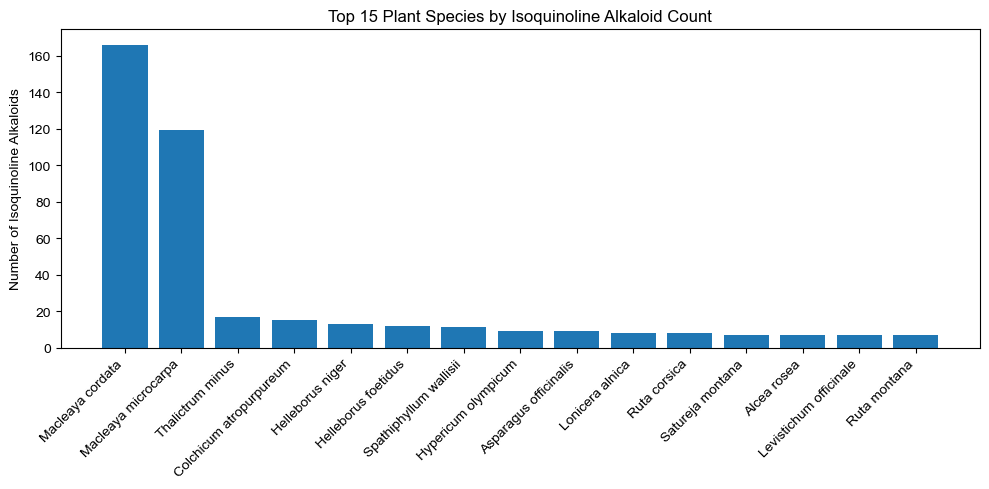

Plot saved to C:\Users\bouch\OneDrive\Plocha\IOCB_Erik\PROJECTS\microfractionation\scripts\jupyter_everything\isoquinoline_alkaloids_per_species_top15.svg


In [4]:
"""
Follow-up Jupyter cell.

Steps:
1) Load feature_table_everything.csv.
2) Filter rows with NPC#class == "Isoquinoline alkaloids".
3) For each plant column, count how many of those features exceed threshold (default 100000).
4) Sort by counts, keep top N (default 15).
5) Plot a bar chart with Matplotlib, styled with Arial, SVG-friendly text, rotated x labels, etc.
6) Save as SVG (default file: isoquinoline_alkaloids_per_species_top15.svg).
"""

# =====================
# ====== PARAMS =======
# =====================

THRESHOLD   = 100000
TOP_N       = 15
FIG_IQ_A  = project_root / f"isoquinoline_alkaloids_per_species_top{TOP_N}.svg"

META_COLS   = [ROWID_COL, "molecularFormula", "NPC#pathway", "NPC#superclass", "NPC#class"]

# =====================
# ====== CODE =========
# =====================

# Style config
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['svg.fonttype'] = 'none'

# Load data
df = pd.read_csv(FTABLE_EVERYTHING)

if "NPC#class" not in df.columns:
    raise KeyError("'NPC#class' column not found in input CSV.")

# Detect plant columns
plant_cols = [c for c in df.columns if c not in META_COLS]
if not plant_cols:
    raise RuntimeError("No plant columns found in input CSV.")

# Filter isoquinoline alkaloids
df_iso = df[df["NPC#class"] == "Isoquinoline alkaloids"]

# Count threshold exceedances per plant
counts = {}
for plant in plant_cols:
    counts[plant] = int((df_iso[plant] > THRESHOLD).sum())

# Sort and take top N
sorted_counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:TOP_N])

# Plot
plt.figure(figsize=(10, 5))
plt.bar(sorted_counts.keys(), sorted_counts.values())
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Isoquinoline Alkaloids')
plt.title(f'Top {TOP_N} Plant Species by Isoquinoline Alkaloid Count')
plt.tight_layout()
plt.savefig(FIG_IQ_A, bbox_inches='tight', dpi=300)
plt.show()

print(f"Plot saved to {FIG_IQ_A}")


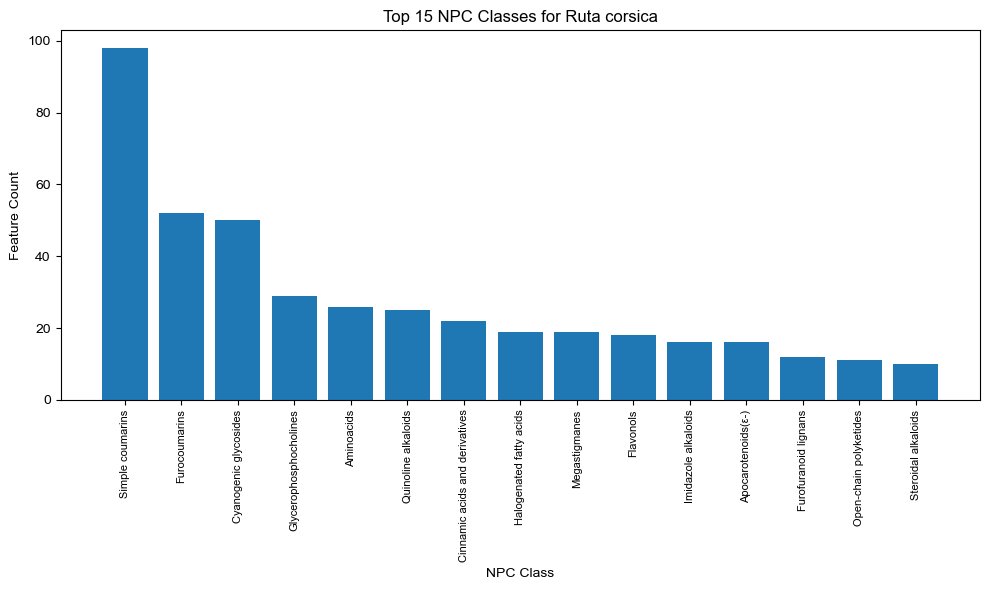

Plot saved to top_15_npc_classes_feature_table_everything.svg


In [5]:
"""
Follow-up Jupyter cell.

Steps:
1) Load feature_table_everything.csv.
2) Select a plant column (PLANT_COL = "Ruta corsica" by default).
3) Keep rows where the area in that plant column > threshold (default 100000).
4) Count occurrences of each NPC#class among those rows.
5) Sort by count, keep top N (default 15).
6) Plot a bar chart with Matplotlib styled like before.
7) Save as SVG file with dynamic name (top_15_npc_classes_feature_table_everything.svg).
"""

import os

# =====================
# ====== PARAMS =======
# =====================

PLANT_COL   = "Ruta corsica"
THRESHOLD   = 100000
TOP_N       = 15

# =====================
# ====== CODE =========
# =====================

# Style config
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['svg.fonttype'] = 'none'

# Load data
df = pd.read_csv(FTABLE_EVERYTHING)

if PLANT_COL not in df.columns:
    raise KeyError(f"Plant column '{PLANT_COL}' not found in {FTABLE_EVERYTHING}")

if "NPC#class" not in df.columns:
    raise KeyError("'NPC#class' column not found in input CSV.")

# Filter rows where plant area > threshold
df_sel = df[df[PLANT_COL] > THRESHOLD]

# Count NPC classes
top_counts = df_sel["NPC#class"].value_counts().head(TOP_N)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(top_counts.index, top_counts.values)
plt.xticks(rotation=90, fontsize=8)
plt.xlabel('NPC Class')
plt.ylabel('Feature Count')
plt.title(f'Top {TOP_N} NPC Classes for {PLANT_COL}')
plt.tight_layout()

# Output filename based on CSV name
csv_base = os.path.basename(FTABLE_EVERYTHING).split(".")[0]
FIG_NPC_CLASS = f"top_{TOP_N}_npc_classes_{csv_base}.svg"
plt.savefig(FIG_NPC_CLASS, bbox_inches='tight', dpi=300)
plt.show()

print(f"Plot saved to {FIG_NPC_CLASS}")
